In [3]:
# ==============================================================
# 1. IMPORT LIBRARIES
# ==============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [4]:
# ==============================================================
# 2. LOAD DATA
# ==============================================================

train_path = r"C:\Users\arman\OneDrive\Desktop\ST_Data\train.csv"
test_path  = r"C:\Users\arman\OneDrive\Desktop\ST_Data\test.csv"

train = pd.read_csv(train_path).copy()
test  = pd.read_csv(test_path).copy()

train.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
# ==============================================================
# 3. PROCESS DATA — WARNING FREE
# ==============================================================

# --------------------------
# Split Cabin column safely
# --------------------------
def split_cabin(df):
    cabin_split = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = cabin_split[0]
    df["CabinNum"] = cabin_split[1]
    df["Side"] = cabin_split[2]
    return df

train = split_cabin(train)
test  = split_cabin(test)

numeric_features = ["Age", "RoomService", "FoodCourt",
                    "ShoppingMall", "Spa", "VRDeck"]

categorical_features = ["HomePlanet", "CryoSleep", "Destination",
                        "VIP", "Deck", "Side"]

# --------------------------
# Fix missing numeric values
# --------------------------
for col in numeric_features:
    median_value = train[col].median()
    train[col] = train[col].fillna(median_value)
    test[col]  = test[col].fillna(median_value)

# --------------------------
# Fix missing categorical values
# --------------------------
for col in categorical_features:
    mode_value = train[col].mode(dropna=True)[0]

    # Fill and preserve dtype as 'object'
    train[col] = train[col].fillna(mode_value).astype("object")
    test[col]  = test[col].fillna(mode_value).astype("object")

# Convert CryoSleep and VIP to boolean (safe)
train["CryoSleep"] = train["CryoSleep"].astype(bool)
test["CryoSleep"]  = test["CryoSleep"].astype(bool)

train["VIP"] = train["VIP"].astype(bool)
test["VIP"]  = test["VIP"].astype(bool)

# --------------------------
# Prepare final DataFrames
# --------------------------
y = train["Transported"].astype(int)

X = train.drop(columns=["Transported", "Name", "PassengerId", "Cabin"])
test_data = test.drop(columns=["Name", "PassengerId", "Cabin"])

# Safe train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train.head()


C:\Users\arman\AppData\Local\Temp\ipykernel_36640\1444447210.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[col] = train[col].fillna(mode_value).astype("object")
C:\Users\arman\AppData\Local\Temp\ipykernel_36640\1444447210.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[col]  = test[col].fillna(mode_value).astype("object")
C:\Users\arman\AppData\Local\Temp\ipykernel_36640\1444447210.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_ob

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side
3600,Earth,False,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,G,630,S
1262,Earth,True,TRAPPIST-1e,17.0,False,0.0,0.0,0.0,0.0,0.0,G,201,S
8612,Earth,False,PSO J318.5-22,35.0,False,0.0,0.0,0.0,0.0,0.0,G,1483,S
5075,Europa,True,55 Cancri e,26.0,False,0.0,0.0,0.0,0.0,0.0,D,164,S
4758,Earth,False,TRAPPIST-1e,13.0,False,0.0,0.0,60.0,1.0,5147.0,G,818,P


In [6]:
# ==============================================================
# 4. LOGISTIC REGRESSION (PAIR A)
# ==============================================================

preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), 
         categorical_features)
    ],
    remainder="drop"
)

log_reg_model = Pipeline(steps=[
    ("prep", preprocess_lr),
    ("model", LogisticRegression(max_iter=500))
])

log_reg_model.fit(X_train, y_train)

pred_lr = log_reg_model.predict(X_val)
prob_lr = log_reg_model.predict_proba(X_val)[:, 1]

acc_lr = accuracy_score(y_val, pred_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_val, prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

print("Logistic Regression Accuracy:", round(acc_lr, 4))
print("Logistic Regression AUC:", round(auc_lr, 4))


Logistic Regression Accuracy: 0.7918
Logistic Regression AUC: 0.8815


In [7]:
# ==============================================================
# 5. DECISION TREE (PAIR B)
# ==============================================================

# Label encoding (warning-free)
encoded_train = X.copy()
encoded_test  = test_data.copy()

for col in categorical_features:
    le = LabelEncoder()
    encoded_train[col] = le.fit_transform(encoded_train[col])
    encoded_test[col]  = le.transform(encoded_test[col])

X_train_dt, X_val_dt, y_train_dt, y_val_dt = train_test_split(
    encoded_train, y, test_size=0.20, stratify=y, random_state=42
)

dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=4,
    random_state=42
)

dt_model.fit(X_train_dt, y_train_dt)

pred_dt = dt_model.predict(X_val_dt)
prob_dt = dt_model.predict_proba(X_val_dt)[:, 1]

acc_dt = accuracy_score(y_val_dt, pred_dt)
fpr_dt, tpr_dt, _ = roc_curve(y_val_dt, prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

print("Decision Tree Accuracy:", round(acc_dt, 4))
print("Decision Tree AUC:", round(auc_dt, 4))


Decision Tree Accuracy: 0.7838
Decision Tree AUC: 0.8587


In [8]:
# ==============================================================
# 6. RANDOM FOREST (ALL MEMBERS)
# ==============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model.fit(X_train_dt, y_train_dt)

pred_rf = rf_model.predict(X_val_dt)
prob_rf = rf_model.predict_proba(X_val_dt)[:, 1]

acc_rf = accuracy_score(y_val_dt, pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_val_dt, prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print("Random Forest Accuracy:", round(acc_rf, 4))
print("Random Forest AUC:", round(auc_rf, 4))


Random Forest Accuracy: 0.8085
Random Forest AUC: 0.8931


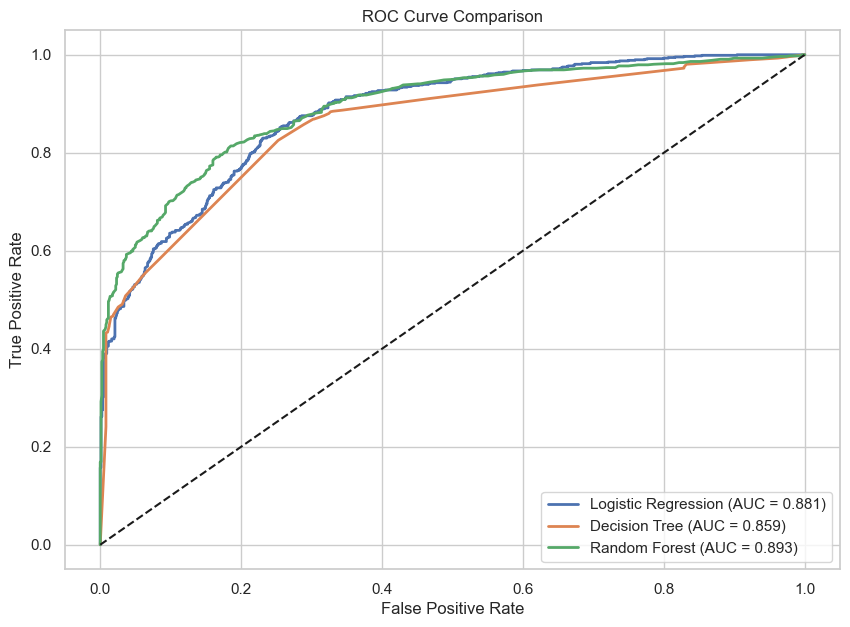

In [9]:
# ==============================================================
# 7. PLOT ROC CURVE COMPARISON (NO WARNINGS)
# ==============================================================

plt.figure(figsize=(10, 7))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# ==============================================================
# 8. PRINT SUMMARY
# ==============================================================

print("\n===== MODEL PERFORMANCE SUMMARY =====")
print(f"Logistic Regression: Accuracy={acc_lr:.3f}, AUC={auc_lr:.3f}")
print(f"Decision Tree:       Accuracy={acc_dt:.3f}, AUC={auc_dt:.3f}")
print(f"Random Forest:       Accuracy={acc_rf:.3f}, AUC={auc_rf:.3f}")



===== MODEL PERFORMANCE SUMMARY =====
Logistic Regression: Accuracy=0.792, AUC=0.881
Decision Tree:       Accuracy=0.784, AUC=0.859
Random Forest:       Accuracy=0.809, AUC=0.893


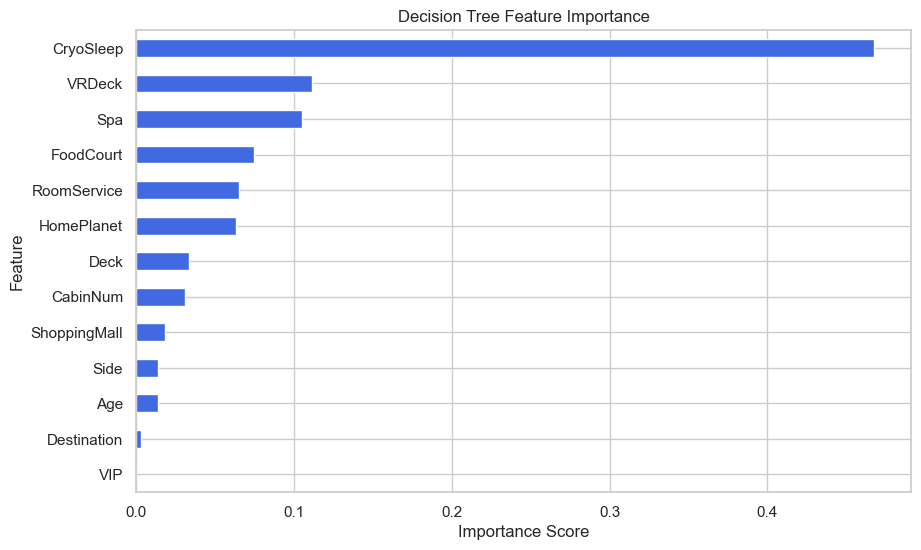

In [11]:
# ==============================================================
# A1. DECISION TREE FEATURE IMPORTANCE
# ==============================================================

importances_dt = pd.Series(dt_model.feature_importances_, index=encoded_train.columns)

plt.figure(figsize=(10, 6))
importances_dt.sort_values().plot(kind="barh", color="royalblue")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


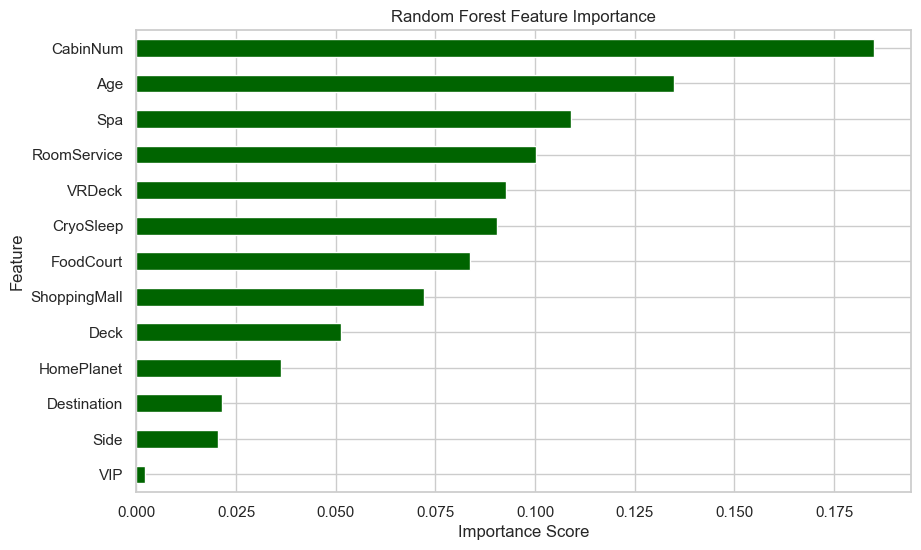

In [12]:
# ==============================================================
# A2. RANDOM FOREST FEATURE IMPORTANCE
# ==============================================================

importances_rf = pd.Series(rf_model.feature_importances_, index=encoded_train.columns)

plt.figure(figsize=(10, 6))
importances_rf.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


In [13]:
# ==============================================================
# B. CROSS-VALIDATION FOR ALL MODELS
# ==============================================================

from sklearn.model_selection import cross_val_score

print("===== CROSS-VALIDATION SCORES =====")

# Logistic Regression CV (pipeline)
cv_lr = cross_val_score(log_reg_model, X, y, cv=5, scoring="accuracy")
print("Logistic Regression CV Accuracy:", cv_lr.mean().round(4))

# Decision Tree CV
cv_dt = cross_val_score(dt_model, encoded_train, y, cv=5, scoring="accuracy")
print("Decision Tree CV Accuracy:", cv_dt.mean().round(4))

# Random Forest CV
cv_rf = cross_val_score(rf_model, encoded_train, y, cv=5, scoring="accuracy")
print("Random Forest CV Accuracy:", cv_rf.mean().round(4))


===== CROSS-VALIDATION SCORES =====
Logistic Regression CV Accuracy: 0.7872
Decision Tree CV Accuracy: 0.759
Random Forest CV Accuracy: 0.7851


In [14]:
# ==============================================================
# C1. GRIDSEARCH FOR LOGISTIC REGRESSION
# ==============================================================

from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "model__C": [0.1, 0.5, 1, 2, 5],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

grid_lr = GridSearchCV(
    log_reg_model,
    param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_lr.best_params_)
print("Best Logistic Regression Score:", grid_lr.best_score_)


Best Logistic Regression Params: {'model__C': 2, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best Logistic Regression Score: 0.7893296577691118


In [15]:
# ==============================================================
# FINAL PREDICTIONS ON TEST DATA
# ==============================================================

# Predict Transported (True/False)
final_prob = rf_model.predict_proba(encoded_test)[:, 1]
final_pred = (final_prob >= 0.5).astype(bool)  # Threshold = 0.5

# Add predictions to a new DataFrame
submission_df = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": final_pred
})

submission_df.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


In [16]:
# ==============================================================
# SHOW ALL PASSENGERS PREDICTED AS TRANSPORTED
# ==============================================================

transported_passengers = submission_df[submission_df["Transported"] == True]

transported_passengers.head(20)  # show first 20

,PassengerId,Transported
0,0013_01,True
2,0019_01,True
3,0021_01,True
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True
12,0040_02,True
13,0042_01,True


In [17]:
# All transported passengers
transported_passengers

,PassengerId,Transported
0,0013_01,True
2,0019_01,True
3,0021_01,True
5,0027_01,True
6,0029_01,True
...,...,...
4267,9260_01,True
4269,9263_01,True
4270,9265_01,True
4274,9271_01,True


In [18]:
# Counting how many passengers were transported
num_transported = transported_passengers.shape[0]
num_total = submission_df.shape[0]

print(f"Transported Passengers: {num_transported} out of {num_total}")

Transported Passengers: 2024 out of 4277
